# Basic code for snn computation 

## Load the data

In [6]:
import numpy as np
data_sc = np.load('/Users/anushka/Undergraduate-Project/ndarrays/sc_data_ndarray.npz')
data_st=np.load('/Users/anushka/Undergraduate-Project/ndarrays/st_data_ndarray.npz')
envi_latent_sc = data_sc['envi_latent']  
covet_sqrt_sc = data_sc['COVET_SQRT']  
envi_latent_st = data_st['envi_latent'] 
covet_sqrt_st = data_st['COVET_SQRT'] 

In [7]:
envi_latent_sc.shape

(7416, 512)

## Concatenate sc and st envi latent and covet srt respectively

In [11]:
envi_latent_combined = np.concatenate((envi_latent_sc, envi_latent_st), axis=0)

In [12]:
covet_sqrt_sc.shape


(7416, 62, 62)

In [13]:
covet_sqrt_st.shape

(18516, 64, 64)

In [14]:
envi_latent_combined.shape

(25932, 512)

In [16]:
covet_sqrt_st.shape

(18516, 64, 64)

### Pad covet_sqrt_sc to 64

In [21]:
covet_sqrt_sc_padded = np.pad(covet_sqrt_sc, ((0, 0), (0, 2), (0, 2)), mode='constant')


In [22]:
covet_sqrt_sc_padded.shape

(7416, 64, 64)

In [23]:
covet_sqrt_combined = np.concatenate((covet_sqrt_sc_padded, covet_sqrt_st), axis=0)


### Flatten covet_sqrt_combined

In [24]:
print(" Flattening COVET_SQRT matrix...")
covet_sqrt_flattened = covet_sqrt_combined.reshape(covet_sqrt_combined.shape[0], -1)
print(f" Flattened COVET_SQRT to shape {covet_sqrt_flattened.shape}")

 Flattening COVET_SQRT matrix...
 Flattened COVET_SQRT to shape (25932, 4096)


## Calculating the SNN Matrix

In [30]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm  # Import tqdm for progress bar

def apply_pca(X: np.ndarray, n_components: int = 20):
    """
    Applies PCA to reduce dimensionality of the dataset.

    Parameters:
    - X (np.ndarray): Input data matrix of shape (n_samples, n_features).
    - n_components (int): Number of principal components to keep.

    Returns:
    - X_pca (np.ndarray): Transformed data matrix with reduced dimensions.
    """
    print(f"Applying PCA: Reducing {X.shape[1]} dimensions to {n_components}...")
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X)
    print(f"PCA complete. Reduced shape: {X_pca.shape}")
    return X_pca

def compute_knn_indices(X: np.ndarray, n_neighbors: int):
    """
    Computes the k-nearest neighbors (KNN) indices and distances for a given dataset.
    """
    print(f"Computing KNN for data of shape {X.shape} with {n_neighbors} neighbors...")
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree', n_jobs=-1).fit(X)
    distances, indices = nbrs.kneighbors(X)  # Efficient KNN computation

    print("KNN computation complete.")
    return indices, distances

def snn_matrix(indices: np.ndarray, n_neighbors: int):
    """
    Computes the Shared Nearest Neighbor (SNN) similarity matrix.
    """
    print(f"Computing SNN matrix for {indices.shape[0]} samples...")
    n_samples = indices.shape[0]
    snn = np.zeros((n_samples, n_samples), dtype=np.float32)
    
    for i in tqdm(range(n_samples), desc="SNN Computation", unit="samples"):
        for j in range(i + 1, n_samples):
            nni = indices[i]
            nnj = indices[j]
            shared = np.intersect1d(nni, nnj)
            
            s = [0]
            for shared_knn in shared:
                s.append(n_neighbors - 0.5 * (np.where(nni == shared_knn)[0][0] + np.where(nnj == shared_knn)[0][0]))
            
            snn[i, j] = max(s)
            snn[j, i] = snn[i, j]  # Ensure symmetry
    
    print("SNN matrix computation complete.")
    return snn

def calculate_final_snn(snn_1: np.ndarray, snn_2: np.ndarray):
    """
    Merges two SNN matrices by computing their element-wise mean.
    """
    print("Merging two SNN matrices...")

    mask = (snn_1 == 0) | (snn_2 == 0)
    snn_1 = snn_1.astype(float)
    snn_2 = snn_2.astype(float)

    snn_1[mask] = np.nan
    snn_2[mask] = np.nan

    # Compute element-wise mean efficiently
    final_snn = np.nanmean(np.stack((snn_1, snn_2), axis=0), axis=0)

    # Replace NaN values with 0
    final_snn[np.isnan(final_snn)] = 0

    print("Final SNN matrix computation complete.")
    return final_snn

def compute_snn(envi_latent_combined: np.ndarray, covet_sqrt_combined: np.ndarray, n_neighbors: int = 10, pca_components: int = 20):
    """
    Computes the final Shared Nearest Neighbor (SNN) similarity matrix after applying PCA.
    Also saves the individual SNN matrices before merging.
    """
    print("Starting SNN computation...")

    # Apply PCA to reduce dimensionality
    #envi_latent_combined = apply_pca(envi_latent_combined, n_components=pca_components)
    covet_sqrt_combined = apply_pca(covet_sqrt_combined, n_components=pca_components)

    print("Processing covet_sqrt_combined matrix...")
    knn_indices_covet, _ = compute_knn_indices(covet_sqrt_combined, n_neighbors)
    snn_covet = snn_matrix(knn_indices_covet, n_neighbors)

    print("Processing envi_latent_combined matrix...")
    knn_indices_envi, _ = compute_knn_indices(envi_latent_combined, n_neighbors)
    snn_envi = snn_matrix(knn_indices_envi, n_neighbors)

    # ✅ Save SNN matrices before merging
    np.save("snn_covet.npy", snn_covet)
    np.save("snn_envi.npy", snn_envi)
    print("Saved snn_covet.npy and snn_envi.npy successfully!")

    print("Combining SNN matrices to compute the final SNN matrix...")
    final_snn = calculate_final_snn(snn_covet, snn_envi)

    print("SNN computation completed successfully!")
    return final_snn


In [32]:

#envi_latent_combined and covet_sqrt_combined should be NumPy arrays of shape (n_samples, n_features)
#final_snn = compute_snn(envi_latent_combined, covet_sqrt_flattened, n_neighbors=10)
covet_sqrt_PCA = apply_pca(covet_sqrt_flattened, n_components=20)




Applying PCA: Reducing 4096 dimensions to 20...
PCA complete. Reduced shape: (25932, 20)


In [33]:
import umap.umap_ as umap

In [34]:
fit = umap.UMAP(n_neighbors=100, min_dist=0.3,n_components=2)
latent_umap = fit.fit_transform(covet_sqrt_PCA)
latent_umap

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[13.969924  ,  1.7074158 ],
       [16.89297   ,  5.6777415 ],
       [11.53025   ,  0.51174617],
       ...,
       [ 0.8608135 ,  1.1995722 ],
       [-1.2234697 ,  2.8984687 ],
       [ 3.2361023 ,  8.0774765 ]], dtype=float32)

<Axes: >

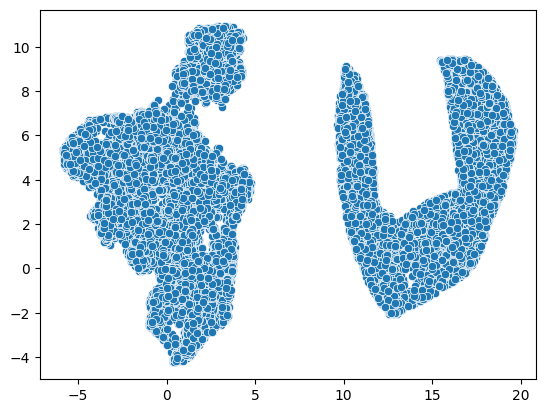

In [ ]:
import seaborn as sns 
sns.scatterplot(x = latent_umap[:,0], y = latent_umap[:,1])